In [1]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.0 MB/s eta 0:00:00a 0:00:01


[GNN] Epoch 001 — Train: 0.2737, Val: 0.2547
[GNN] Epoch 002 — Train: 0.2067, Val: 0.2068
[GNN] Epoch 003 — Train: 0.1884, Val: 0.1759
[GNN] Epoch 004 — Train: 0.1776, Val: 0.1615
[GNN] Epoch 005 — Train: 0.1708, Val: 0.1546
[GNN] Epoch 006 — Train: 0.1639, Val: 0.1509
[GNN] Epoch 007 — Train: 0.1620, Val: 0.1492
[GNN] Epoch 008 — Train: 0.1609, Val: 0.1475
[GNN] Epoch 009 — Train: 0.1590, Val: 0.1463
[GNN] Epoch 010 — Train: 0.1573, Val: 0.1456
[GNN] Epoch 011 — Train: 0.1554, Val: 0.1446
[GNN] Epoch 012 — Train: 0.1542, Val: 0.1437
[GNN] Epoch 013 — Train: 0.1534, Val: 0.1436
[GNN] Epoch 014 — Train: 0.1546, Val: 0.1425
[GNN] Epoch 015 — Train: 0.1526, Val: 0.1417
[GNN] Epoch 016 — Train: 0.1512, Val: 0.1406
[GNN] Epoch 017 — Train: 0.1515, Val: 0.1406
[GNN] Epoch 018 — Train: 0.1511, Val: 0.1406
[GNN] Epoch 019 — Train: 0.1490, Val: 0.1398
[GNN] Epoch 020 — Train: 0.1476, Val: 0.1388
[GNN] Epoch 021 — Train: 0.1482, Val: 0.1398
[GNN] Epoch 022 — Train: 0.1481, Val: 0.1392
[GNN] Epoc

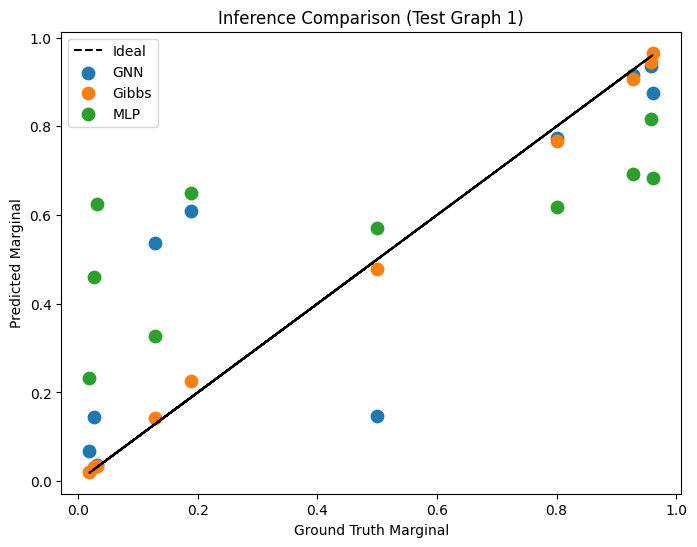

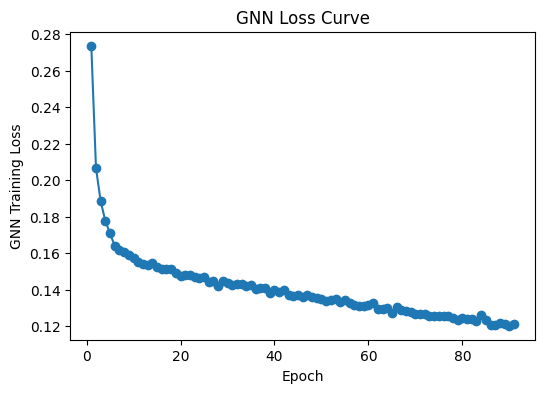

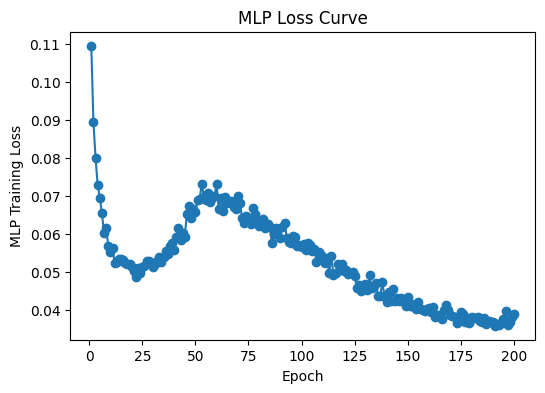

In [9]:
#!/usr/bin/env python
"""
Improved Approximate Inference in Binary MRFs with GNN + MLP Baseline
- Fixed MLP target stacking (now y_train shape is [N_samples, num_nodes])
- Validation‐like test set for early stopping
- AdamW + weight decay
- OneCycleLR scheduler
- BatchNorm + Dropout
- Scatter‐ and loss‐curve plots under outputs/
"""

import os
import numpy as np
import networkx as nx
import itertools
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import NNConv, TransformerConv

###################################
# 1. Synthetic Data Generation
###################################
def generate_random_mrf(num_nodes, edge_prob=0.5, seed=None):
    if seed is not None:
        np.random.seed(seed)
    G = nx.erdos_renyi_graph(num_nodes, edge_prob)
    b = np.random.uniform(-1, 1, size=(num_nodes,))
    J = np.zeros((num_nodes, num_nodes))
    for i, j in G.edges():
        w = np.random.randn()
        J[i, j] = J[j, i] = w
    for i, j in G.edges():
        G[i][j]['weight'] = J[i][j]
    return G, b, J

def compute_exact_marginals(b, J):
    n = len(b)
    assignments = np.array(list(itertools.product([-1, 1], repeat=n)))
    lin = assignments @ b
    quad = 0.5 * np.einsum('bi,ij,bj->b', assignments, J, assignments)
    pot = np.exp(lin + quad)
    Z = pot.sum()
    return np.array([pot[assignments[:, i] == 1].sum() / Z for i in range(n)])

def gibbs_sampler(b, J, num_iter=5000, burn_in=1000):
    n = len(b)
    state = np.ones(n, dtype=int)
    samples = []
    for it in range(num_iter):
        for i in range(n):
            p = 1.0 / (1 + np.exp(-2 * (b[i] + J[i] @ state)))
            state[i] = 1 if np.random.rand() < p else -1
        if it >= burn_in:
            samples.append(state.copy())
    return np.mean(np.array(samples) == 1, axis=0)

###################################
# 2. Data Representation
###################################
def create_data_object(G, b, J, marginals):
    x = torch.tensor(b, dtype=torch.float32).unsqueeze(1)
    edges = torch.tensor(list(G.edges()), dtype=torch.long).t().contiguous()
    edges = torch.cat([edges, edges[[1, 0]]], dim=1)
    edge_attr = []
    for i, j in edges.t().tolist():
        w = G[i][j].get('weight', 0.0)
        edge_attr.append([w, b[i], b[j]])
    edge_attr = torch.tensor(edge_attr, dtype=torch.float32)
    y = torch.tensor(marginals, dtype=torch.float32).unsqueeze(1)
    data = Data(x=x, edge_index=edges, edge_attr=edge_attr, y=y)
    data.gibbs = torch.tensor(gibbs_sampler(b, J), dtype=torch.float32).unsqueeze(1)
    return data

def vectorize_graph_features(b, J):
    n = len(b)
    triu = np.triu_indices(n, k=1)
    return np.concatenate([b, J[triu]])

###################################
# 3. Models
###################################
class DynamicEdgeUpdate(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(2*node_dim + edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, edge_dim)
        )
    def forward(self, x, edge_index, edge_attr):
        src, dst = edge_index
        h = torch.cat([x[src], x[dst], edge_attr], dim=1)
        return self.mlp(h)

class GraphTransformerGNN(nn.Module):
    def __init__(self, in_c, hid_c, edge_c, out_c, num_layers=3, heads=4, dropout=0.2):
        super().__init__()
        self.edge_net = nn.Sequential(
            nn.Linear(edge_c, 64), nn.ReLU(),
            nn.Linear(64, in_c*hid_c)
        )
        self.nnconv = NNConv(in_c, hid_c, self.edge_net, aggr='mean')
        self.bn0 = nn.BatchNorm1d(hid_c)
        self.dropout = nn.Dropout(dropout)
        self.edge_update = DynamicEdgeUpdate(hid_c, edge_c, 64)
        self.trans = nn.ModuleList()
        self.bns   = nn.ModuleList()
        for _ in range(num_layers):
            self.trans.append(
                TransformerConv(hid_c, hid_c, heads=heads, concat=False, dropout=dropout)
            )
            self.bns.append(nn.BatchNorm1d(hid_c))
        self.lin = nn.Linear(hid_c, out_c)

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        x = torch.relu(self.bn0(self.nnconv(x, edge_index, edge_attr)))
        edge_attr = self.edge_update(x, edge_index, edge_attr)
        for conv, bn in zip(self.trans, self.bns):
            x_new = conv(self.dropout(x), edge_index)
            x = torch.relu(bn(x + x_new))
        return torch.sigmoid(self.lin(x))

class MRF_MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_nodes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_nodes)
        )
    def forward(self, x):
        return torch.sigmoid(self.net(x)).unsqueeze(2)

###################################
# 4. Losses & Utilities
###################################
def kl_bernoulli_loss(pred, target, eps=1e-8):
    return torch.mean(
        target*torch.log((target+eps)/(pred+eps)) +
        (1-target)*torch.log((1-target+eps)/(1-pred+eps))
    )

def combined_loss(pred, target, mse_w=1.0, kl_w=0.5, ent_w=0.1):
    mse = nn.MSELoss()(pred, target)
    kl  = kl_bernoulli_loss(pred, target)
    ent = - (pred*torch.log(pred+1e-8) + (1-pred)*torch.log(1-pred+1e-8)).mean()
    return mse_w*mse + kl_w*kl + ent_w*ent

class EarlyStopper:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience, self.min_delta = patience, min_delta
        self.best, self.counter = np.inf, 0
    def __call__(self, curr):
        if curr + self.min_delta < self.best:
            self.best, self.counter = curr, 0
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience

def train_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total, count = 0., 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = loss_fn(out, data.y.to(device))
        loss.backward()
        optimizer.step()
        total += loss.item() * data.num_nodes
        count += data.num_nodes
    return total / count

def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    total, count = 0., 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            total += loss_fn(out, data.y.to(device)).item() * data.num_nodes
            count += data.num_nodes
    return total / count

###################################
# 5. Main Script: Training & Plots
###################################
def main():
    torch.manual_seed(42)
    np.random.seed(42)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    os.makedirs('outputs', exist_ok=True)

    # Hyperparameters
    NODES, EPROB = 10, 0.5
    N_TRAIN, N_TEST = 500, 100
    BATCH = 32
    EPOCHS_GNN = 200
    EPOCHS_MLP = 200

    # Generate training data
    gnn_train, mlp_X_train, mlp_y_train = [], [], []
    for i in range(N_TRAIN):
        G, b, J = generate_random_mrf(NODES, EPROB, seed=42+i)
        marg = compute_exact_marginals(b, J)
        gnn_train.append(create_data_object(G, b, J, marg))
        mlp_X_train.append(vectorize_graph_features(b, J))
        mlp_y_train.append(marg)                      # now 1D

    # Generate test data
    gnn_test, mlp_X_test, mlp_y_test = [], [], []
    for i in range(N_TEST):
        G, b, J = generate_random_mrf(NODES, EPROB, seed=1000+i)
        marg = compute_exact_marginals(b, J)
        gnn_test.append(create_data_object(G, b, J, marg))
        mlp_X_test.append(vectorize_graph_features(b, J))
        mlp_y_test.append(marg)

    # DataLoaders for GNN
    gnn_train_loader = DataLoader(gnn_train, batch_size=BATCH, shuffle=True)
    gnn_test_loader  = DataLoader(gnn_test,  batch_size=BATCH)

    # Convert MLP data
    X_train = np.vstack(mlp_X_train)               # shape (N_TRAIN, feat_dim)
    y_train = np.vstack(mlp_y_train)               # shape (N_TRAIN, NODES)
    X_test  = np.vstack(mlp_X_test)                # shape (N_TEST, feat_dim)
    y_test  = np.vstack(mlp_y_test)                # shape (N_TEST, NODES)

    # ——— Train GNN ———
    model_gnn = GraphTransformerGNN(1, 64, 3, 1).to(device)
    opt_gnn   = optim.AdamW(model_gnn.parameters(), lr=5e-3, weight_decay=1e-4)
    sch_gnn   = OneCycleLR(opt_gnn, max_lr=1e-2,
                           steps_per_epoch=len(gnn_train_loader), epochs=EPOCHS_GNN)
    stopper   = EarlyStopper(patience=15)

    gnn_train_losses = []
    for ep in range(1, EPOCHS_GNN+1):
        tr_loss = train_epoch(model_gnn, gnn_train_loader, opt_gnn, combined_loss, device)
        gnn_train_losses.append(tr_loss)
        val_loss = eval_epoch(model_gnn, gnn_test_loader, combined_loss, device)
        sch_gnn.step()
        print(f"[GNN] Epoch {ep:03d} — Train: {tr_loss:.4f}, Val: {val_loss:.4f}")
        if stopper(val_loss):
            print("GNN early stopping.")
            break

    mse_gnn = eval_epoch(model_gnn, gnn_test_loader, lambda p,t: nn.MSELoss()(p,t), device)
    print("GNN Test MSE:", mse_gnn)

    # ——— Train MLP ———
    model_mlp = MRF_MLP(X_train.shape[1], 128, NODES).to(device)
    opt_mlp   = optim.AdamW(model_mlp.parameters(), lr=1e-2, weight_decay=1e-4)
    sch_mlp   = OneCycleLR(opt_mlp, max_lr=1e-1,
                           steps_per_epoch=int(np.ceil(N_TRAIN/BATCH)), epochs=EPOCHS_MLP)

    mlp_train_losses = []
    for ep in range(1, EPOCHS_MLP+1):
        model_mlp.train()
        perm = np.random.permutation(N_TRAIN)
        run_loss = 0.0
        for i in range(0, N_TRAIN, BATCH):
            idx = perm[i:i+BATCH]
            xb = torch.tensor(X_train[idx], dtype=torch.float32).to(device)
            yb = torch.tensor(y_train[idx], dtype=torch.float32).to(device)
            opt_mlp.zero_grad()
            out = model_mlp(xb).squeeze(2)      # shape (batch, NODES)
            loss = nn.MSELoss()(out, yb)
            loss.backward()
            opt_mlp.step()
            sch_mlp.step()
            run_loss += loss.item() * len(idx)
        ep_loss = run_loss / N_TRAIN
        mlp_train_losses.append(ep_loss)
        if ep % 10 == 0:
            print(f"[MLP] Epoch {ep:03d} — Train Loss: {ep_loss:.4f}")

    model_mlp.eval()
    with torch.no_grad():
        out_mlp = model_mlp(torch.tensor(X_test, dtype=torch.float32).to(device))\
                    .cpu().numpy().squeeze(2)
    mse_mlp = np.mean((out_mlp - y_test)**2)
    print("MLP Test MSE:", mse_mlp)

    # ——— Visualization ———
    test_obj   = gnn_test[0]
    gt         = test_obj.y.numpy().flatten()
    gnn_pred   = model_gnn(test_obj.to(device)).cpu().detach().numpy().flatten()
    #gibbs_pred = test_obj.gibbs.numpy().flatten()
    gibbs_pred = test_obj.gibbs.cpu().numpy().flatten()

    mlp_pred   = out_mlp[0]

    plt.figure(figsize=(8,6))
    plt.plot(gt, gt, 'k--', label='Ideal')
    plt.scatter(gt, gnn_pred, s=80, label='GNN')
    plt.scatter(gt, gibbs_pred, s=80, label='Gibbs')
    plt.scatter(gt, mlp_pred, s=80, label='MLP')
    plt.xlabel("Ground Truth Marginal")
    plt.ylabel("Predicted Marginal")
    plt.title("Inference Comparison (Test Graph 1)")
    plt.legend()
    plt.savefig("outputs/inference_comparison.png")
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(range(1, len(gnn_train_losses)+1), gnn_train_losses, marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("GNN Training Loss")
    plt.title("GNN Loss Curve")
    plt.savefig("outputs/gnn_loss.png")
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(range(1, len(mlp_train_losses)+1), mlp_train_losses, marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("MLP Training Loss")
    plt.title("MLP Loss Curve")
    plt.savefig("outputs/mlp_loss.png")
    plt.show()

if __name__ == "__main__":
    main()
